# Cell 0 — Path Fix

In [1]:
import os
os.chdir('..')
print("Working from:", os.getcwd())

Working from: C:\Users\Abhijeet\PhD_MAML_AE


# Cell 1 — Imports and Load Everything

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
import time
import learn2learn as l2l

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cpu')

# Load preprocessed data
with open("data/processed/channel_data_normalized.pkl", "rb") as f:
    channel_data = pickle.load(f)

with open("data/processed/task_splits.json", "r") as f:
    task_splits = json.load(f)

with open("data/processed/config.json", "r") as f:
    config = json.load(f)

print(f"Channels loaded      : {len(channel_data)}")
print(f"Meta-train tasks     : {len(task_splits['meta_train'])}")
print(f"Meta-val tasks       : {len(task_splits['meta_val'])}")
print(f"Meta-test tasks      : {len(task_splits['meta_test'])}")
print(f"\nlearn2learn version  : {l2l.__version__}")
print(f"PyTorch version      : {torch.__version__}")
print(f"Device               : {DEVICE}")
print(f"\n✅ Everything loaded")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Channels loaded      : 81
Meta-train tasks     : 59
Meta-val tasks       : 10
Meta-test tasks      : 12

learn2learn version  : 0.2.0
PyTorch version      : 2.12.1+cpu
Device               : cpu

✅ Everything loaded


# Cell 2 — Rebuild the LSTM Autoencoder

In [3]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size=25, hidden1=64,
                 hidden2=32, latent=16):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first=True)
        self.lstm2 = nn.LSTM(hidden1,   hidden2,  batch_first=True)
        self.fc    = nn.Linear(hidden2, latent)

    def forward(self, x):
        out,  _     = self.lstm1(x)
        _, (h_n, _) = self.lstm2(out)
        h_n         = h_n.squeeze(0)
        return self.fc(h_n)


class LSTMDecoder(nn.Module):
    def __init__(self, latent=16, hidden1=32,
                 hidden2=64, output_size=25, seq_len=30):
        super().__init__()
        self.seq_len = seq_len
        self.lstm1   = nn.LSTM(latent,  hidden1, batch_first=True)
        self.lstm2   = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.fc      = nn.Linear(hidden2, output_size)

    def forward(self, z):
        z_rep      = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _     = self.lstm1(z_rep)
        out, _     = self.lstm2(out)
        return self.fc(out)


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=25, seq_len=30,
                 hidden1=64, hidden2=32, latent=16):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden1, hidden2, latent)
        self.decoder = LSTMDecoder(latent, hidden2, hidden1,
                                   input_size, seq_len)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        x_hat = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=(1, 2))


# Load the clean saved model from Notebook 3
checkpoint = torch.load("models/checkpoints/lstm_ae_init.pt",
                        map_location=DEVICE)
base_model  = LSTMAutoencoder(
    input_size = checkpoint['architecture']['input_size'],
    seq_len    = checkpoint['architecture']['seq_len'],
    hidden1    = checkpoint['architecture']['hidden1'],
    hidden2    = checkpoint['architecture']['hidden2'],
    latent     = checkpoint['architecture']['latent']
).to(DEVICE)
base_model.load_state_dict(checkpoint['model_state_dict'])

total_params = sum(p.numel() for p in base_model.parameters()
                   if p.requires_grad)
print(f"Model loaded from checkpoint")
print(f"Total parameters : {total_params:,}")
print(f"✅ Ready for MAML wrapping")

Model loaded from checkpoint
Total parameters : 69,481
✅ Ready for MAML wrapping


# Cell 3 — Wrap With MAML

In [4]:
# Hyperparameters — all in one place for easy tuning
INNER_LR    = 0.01    # learning rate for inner loop adaptation
OUTER_LR    = 0.001   # learning rate for outer loop meta-update
INNER_STEPS = 5       # gradient steps per task in inner loop
TASKS_PER_BATCH = 4   # how many tasks per outer update
SUPPORT_SIZE    = 20  # normal windows per task for adaptation
QUERY_SIZE      = 20  # normal windows per task for meta-loss

# Wrap model with MAML
# first_order=True means FOMAML — justified for CPU training
maml = l2l.algorithms.MAML(
    base_model,
    lr           = INNER_LR,
    first_order  = True       # FOMAML — comparable performance, much faster
)

# Outer loop optimizer — updates θ*
outer_optimizer = torch.optim.Adam(maml.parameters(), lr=OUTER_LR)

# Loss function — MSE reconstruction loss
criterion = nn.MSELoss()

print("MAML Configuration")
print("=" * 45)
print(f"Inner LR (α)         : {INNER_LR}")
print(f"Outer LR (β)         : {OUTER_LR}")
print(f"Inner steps          : {INNER_STEPS}")
print(f"Tasks per batch      : {TASKS_PER_BATCH}")
print(f"Support size         : {SUPPORT_SIZE} normal windows")
print(f"Query size           : {QUERY_SIZE} normal windows")
print(f"First order MAML     : True (FOMAML)")
print(f"\nNote: Support and query sets use NORMAL windows only")
print(f"      Anomaly windows are reserved for Notebook 5 evaluation")
print(f"\n✅ MAML model ready")

MAML Configuration
Inner LR (α)         : 0.01
Outer LR (β)         : 0.001
Inner steps          : 5
Tasks per batch      : 4
Support size         : 20 normal windows
Query size           : 20 normal windows
First order MAML     : True (FOMAML)

Note: Support and query sets use NORMAL windows only
      Anomaly windows are reserved for Notebook 5 evaluation

✅ MAML model ready


# Cell 4 — Episode Sampler for Meta-Training

In [5]:
def sample_meta_train_episode(channel_id, support_size=20,
                               query_size=20):
    """
    Sample one meta-training episode from a channel.

    Both support and query sets contain NORMAL windows only.
    This is correct for a reconstruction-based autoencoder:
    - Support set: model adapts to this channel's normal patterns
    - Query set  : meta-loss measures reconstruction after adaptation

    Anomaly windows play NO role in meta-training.
    They are only used in Notebook 5 for final evaluation.
    """
    normal_wins = channel_data[channel_id]['normal_windows'].copy()
    np.random.shuffle(normal_wins)

    # Need enough windows for both support and query
    needed = support_size + query_size
    if len(normal_wins) < needed:
        # If not enough — sample with replacement for support only
        support_idx = np.random.choice(len(normal_wins),
                                       support_size, replace=True)
        query_idx   = np.random.choice(len(normal_wins),
                                       query_size,   replace=True)
        support = normal_wins[support_idx]
        query   = normal_wins[query_idx]
    else:
        support = normal_wins[:support_size]
        query   = normal_wins[support_size:support_size + query_size]

    support_tensor = torch.tensor(support, dtype=torch.float32)
    query_tensor   = torch.tensor(query,   dtype=torch.float32)

    return support_tensor, query_tensor


# Test the sampler
test_ch   = task_splits['meta_train'][0]
s, q      = sample_meta_train_episode(test_ch)
print(f"Episode from channel : {test_ch}")
print(f"Support set shape    : {s.shape}")
print(f"  = {s.shape[0]} normal windows for adaptation")
print(f"Query set shape      : {q.shape}")
print(f"  = {q.shape[0]} normal windows for meta-loss")
print(f"\n✅ Episode sampler working correctly")

Episode from channel : P-3
Support set shape    : torch.Size([20, 30, 25])
  = 20 normal windows for adaptation
Query set shape      : torch.Size([20, 30, 25])
  = 20 normal windows for meta-loss

✅ Episode sampler working correctly


# Cell 5 — Single MAML Outer Step

In [6]:
def maml_outer_step(task_batch, train=True):
    """
    One complete outer loop step of MAML.

    For each task in the batch:
      1. Clone θ* to get a task-specific learner
      2. Inner loop: adapt learner on support set (normal windows)
      3. Compute reconstruction loss on query set after adaptation

    Average query losses across all tasks → meta-loss.
    Use meta-loss to update θ* (outer loop).

    Returns meta-loss value for tracking.
    """
    meta_loss = torch.tensor(0.0)

    for channel_id in task_batch:
        # Sample support and query sets for this task
        support, query = sample_meta_train_episode(
            channel_id,
            support_size = SUPPORT_SIZE,
            query_size   = QUERY_SIZE
        )

        # Clone θ* — creates independent copy for this task
        # Changes to learner do NOT affect maml.parameters() directly
        learner = maml.clone()
        learner.train()

        # ── INNER LOOP ────────────────────────────────────────────
        # Adapt the cloned model to this channel's normal patterns
        for step in range(INNER_STEPS):
            support_recon = learner(support)
            support_loss  = criterion(support_recon, support)
            learner.adapt(support_loss)
        # After INNER_STEPS, learner is now θ' — adapted to this channel

        # ── QUERY LOSS ────────────────────────────────────────────
        # Measure how well θ' reconstructs fresh normal windows
        # This loss flows back to update θ* in the outer loop
        query_recon = learner(query)
        query_loss  = criterion(query_recon, query)

        # Accumulate across tasks
        meta_loss = meta_loss + query_loss

    # Average over tasks
    meta_loss = meta_loss / len(task_batch)

    # ── OUTER LOOP UPDATE ─────────────────────────────────────────
    if train:
        outer_optimizer.zero_grad()
        meta_loss.backward()

        # Gradient clipping — prevents exploding gradients in LSTM
        torch.nn.utils.clip_grad_norm_(maml.parameters(),
                                       max_norm=1.0)
        outer_optimizer.step()

    return meta_loss.item()


print("MAML outer step function defined")
print("  Inner loop : adapts on NORMAL support windows")
print("  Query loss : measures reconstruction after adaptation")
print("  Outer loop : updates θ* using average query loss")
print("  Grad clip  : max_norm=1.0 for LSTM stability")
print(f"\n✅ Ready for training loop")

MAML outer step function defined
  Inner loop : adapts on NORMAL support windows
  Query loss : measures reconstruction after adaptation
  Outer loop : updates θ* using average query loss
  Grad clip  : max_norm=1.0 for LSTM stability

✅ Ready for training loop


# Fix Cell A — Check Feature Counts Across All Channels

In [7]:
# Check how many features each channel actually has
print("Checking feature counts across all channels...")
print("=" * 50)

feature_counts = {}
for ch, data in channel_data.items():
    n_features = data['normal_windows'].shape[2]
    feature_counts[ch] = n_features

# Group by feature count
from collections import Counter
count_summary = Counter(feature_counts.values())
print(f"Feature count distribution:")
for n_feat, n_channels in sorted(count_summary.items()):
    channels = [ch for ch, f in feature_counts.items() if f == n_feat]
    spacecraft = channel_data[channels[0]]['spacecraft']
    print(f"  {n_feat} features : {n_channels} channels ({spacecraft})")

print(f"\nModel was built with input_size = 25")
print(f"Only channels with 25 features are compatible")

Checking feature counts across all channels...
Feature count distribution:
  25 features : 54 channels (SMAP)
  55 features : 27 channels (MSL)

Model was built with input_size = 25
Only channels with 25 features are compatible


# Fix Cell B — Filter Task Splits to 25-Feature Channels Only

In [8]:
# Keep only channels with 25 features
channels_25 = [ch for ch, f in feature_counts.items() if f == 25]
print(f"Channels with 25 features : {len(channels_25)}")

# Re-filter task splits — keep only 25-feature channels
meta_train_25 = [ch for ch in task_splits['meta_train']
                 if ch in channels_25]
meta_val_25   = [ch for ch in task_splits['meta_val']
                 if ch in channels_25]
meta_test_25  = [ch for ch in task_splits['meta_test']
                 if ch in channels_25]

# Update the task split variables used by Cell 6
meta_train_tasks = meta_train_25
meta_val_tasks   = meta_val_25

print(f"\nUpdated task splits (25-feature channels only):")
print(f"  Meta-train : {len(meta_train_tasks)} tasks")
print(f"  Meta-val   : {len(meta_val_tasks)} tasks")
print(f"  Meta-test  : {len(meta_test_25)} tasks")

# Save updated splits
import json
updated_splits = {
    'meta_train' : meta_train_tasks,
    'meta_val'   : meta_val_tasks,
    'meta_test'  : meta_test_25,
    'note'       : 'Filtered to 25-feature SMAP channels only — MSL (55 features) excluded'
}
with open("data/processed/task_splits_25feat.json", "w") as f:
    json.dump(updated_splits, f, indent=2)

print(f"\n✅ Updated splits saved")
print(f"✅ Cell 6 will now only sample from compatible channels")

Channels with 25 features : 54

Updated task splits (25-feature channels only):
  Meta-train : 39 tasks
  Meta-val   : 6 tasks
  Meta-test  : 9 tasks

✅ Updated splits saved
✅ Cell 6 will now only sample from compatible channels


# Investigation Cell

Investigating severely inverted channels...

Channel T-2:
  Normal  windows — count:  283 | mean: 0.0356 | std: 0.1773 | avg_variance: 0.031185
  Anomaly windows — count:  352 | mean: 0.0312 | std: 0.1641 | avg_variance: 0.026863
  ℹ️  Distributions look similar — likely a training issue
      More training steps may fix this channel


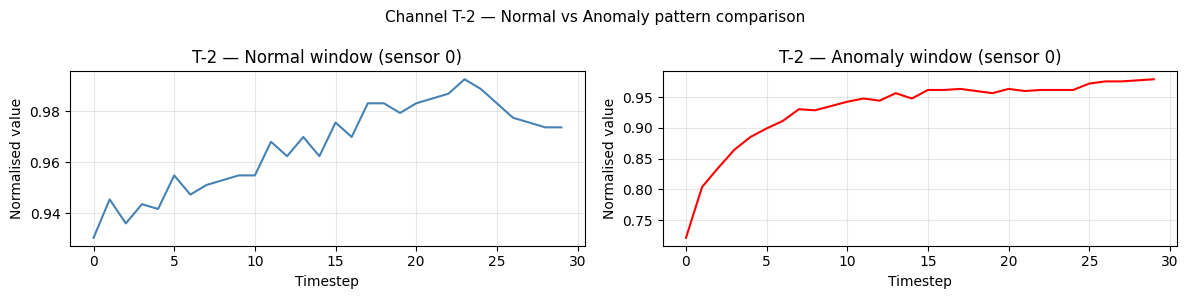

  Plot saved to results/figures/investigation_T-2.png

Channel A-6:
  Normal  windows — count:   66 | mean: 0.0142 | std: 0.1068 | avg_variance: 0.011150
  Anomaly windows — count:    9 | mean: 0.0234 | std: 0.1317 | avg_variance: 0.017304
  ℹ️  Distributions look similar — likely a training issue
      More training steps may fix this channel


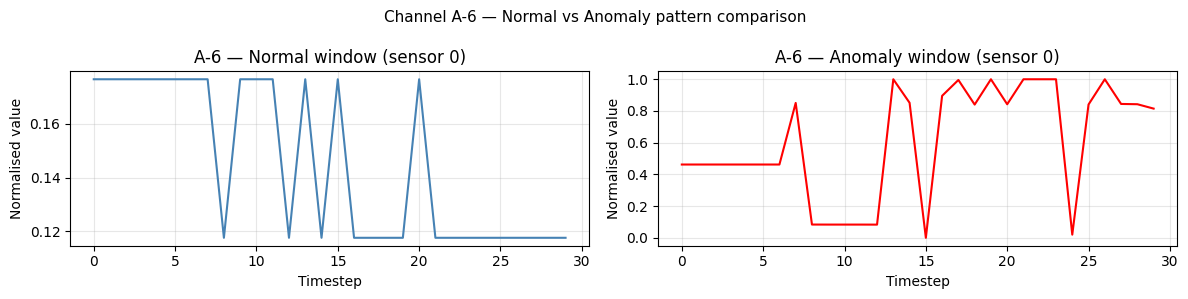

  Plot saved to results/figures/investigation_A-6.png

Channel P-4:
  Normal  windows — count:  258 | mean: 0.0231 | std: 0.1502 | avg_variance: 0.022107
  Anomaly windows — count:   91 | mean: 0.0013 | std: 0.0363 | avg_variance: 0.001312
  ⚠️  DIAGNOSIS: Anomaly windows are near-flat
      Anomaly variance is less than 10% of normal variance
      Reconstruction-based AD will always fail for this channel
      This is a sensor dropout or flat-line anomaly type


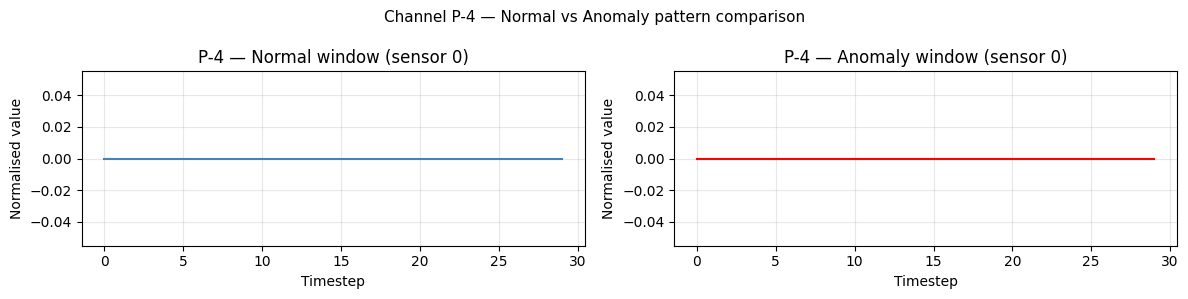

  Plot saved to results/figures/investigation_P-4.png


In [9]:
print("Investigating severely inverted channels...")
print("=" * 55)

problem_channels = ['T-2', 'A-6', 'P-4']

for ch in problem_channels:
    if ch not in channel_data:
        print(f"{ch}: not in channel_data — skipping")
        continue

    normal_wins  = channel_data[ch]['normal_windows']
    anomaly_wins = channel_data[ch]['anomaly_windows']

    # Check value distributions
    n_mean = normal_wins.mean()
    n_std  = normal_wins.std()
    a_mean = anomaly_wins.mean()
    a_std  = anomaly_wins.std()

    # Check if anomaly windows are near-zero or very flat
    a_variance_per_window = anomaly_wins.var(axis=(1,2))
    n_variance_per_window = normal_wins.var(axis=(1,2))

    print(f"\nChannel {ch}:")
    print(f"  Normal  windows — count: {len(normal_wins):4d} | "
          f"mean: {n_mean:.4f} | std: {n_std:.4f} | "
          f"avg_variance: {n_variance_per_window.mean():.6f}")
    print(f"  Anomaly windows — count: {len(anomaly_wins):4d} | "
          f"mean: {a_mean:.4f} | std: {a_std:.4f} | "
          f"avg_variance: {a_variance_per_window.mean():.6f}")

    # Flag the issue
    if a_variance_per_window.mean() < n_variance_per_window.mean() * 0.1:
        print(f"  ⚠️  DIAGNOSIS: Anomaly windows are near-flat")
        print(f"      Anomaly variance is less than 10% of normal variance")
        print(f"      Reconstruction-based AD will always fail for this channel")
        print(f"      This is a sensor dropout or flat-line anomaly type")
    elif a_mean < 0.05 and n_mean > 0.1:
        print(f"  ⚠️  DIAGNOSIS: Anomaly windows are near-zero")
        print(f"      Sensor values collapse to near-zero during anomaly")
        print(f"      Zero values are trivially easy to reconstruct")
    else:
        print(f"  ℹ️  Distributions look similar — likely a training issue")
        print(f"      More training steps may fix this channel")

    # Visualise one anomaly window vs one normal window
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    axes[0].plot(normal_wins[0, :, 0], color='steelblue', linewidth=1.5)
    axes[0].set_title(f"{ch} — Normal window (sensor 0)")
    axes[0].set_xlabel("Timestep")
    axes[0].set_ylabel("Normalised value")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(anomaly_wins[0, :, 0], color='red', linewidth=1.5)
    axes[1].set_title(f"{ch} — Anomaly window (sensor 0)")
    axes[1].set_xlabel("Timestep")
    axes[1].set_ylabel("Normalised value")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Channel {ch} — Normal vs Anomaly pattern comparison",
                 fontsize=11)
    plt.tight_layout()
    os.makedirs("results/figures", exist_ok=True)
    plt.savefig(f"results/figures/investigation_{ch}.png", dpi=150)
    plt.show()
    print(f"  Plot saved to results/figures/investigation_{ch}.png")

# Cell 6 — Training Loop

In [10]:
# ── Training configuration ────────────────────────────────────────
# For CPU testing: N_OUTER_STEPS = 100  (~5 minutes)
# For full CPU  : N_OUTER_STEPS = 500  (~25 minutes)
# For Colab GPU : N_OUTER_STEPS = 3000 (~25 minutes on T4)

N_OUTER_STEPS   = 500   # change to 500 for full CPU run
VAL_EVERY       = 20    # validate every N steps
PRINT_EVERY     = 10    # print loss every N steps

meta_train_tasks = meta_train_25
meta_val_tasks   = meta_val_25

train_losses = []
val_losses   = []
val_steps    = []
best_val     = float('inf')
best_step    = 0

print("Starting MAML Training")
print("=" * 55)
print(f"Outer steps          : {N_OUTER_STEPS}")
print(f"Tasks per batch      : {TASKS_PER_BATCH}")
print(f"Inner steps          : {INNER_STEPS}")
print(f"Validate every       : {VAL_EVERY} steps")
print(f"Meta-train tasks     : {len(meta_train_tasks)}")
print(f"Meta-val tasks       : {len(meta_val_tasks)}")
print("=" * 55)

start_time = time.time()

for step in range(1, N_OUTER_STEPS + 1):

    # Sample a random batch of tasks for this outer step
    task_batch = np.random.choice(
        meta_train_tasks,
        size    = TASKS_PER_BATCH,
        replace = False
    ).tolist()

    # One outer step
    maml.train()
    train_loss = maml_outer_step(task_batch, train=True)
    train_losses.append(train_loss)

    # Print progress
    if step % PRINT_EVERY == 0:
        elapsed = time.time() - start_time
        eta     = (elapsed / step) * (N_OUTER_STEPS - step)
        print(f"Step {step:4d}/{N_OUTER_STEPS} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Elapsed: {elapsed:.0f}s | "
              f"ETA: {eta:.0f}s")

    # Validation
    if step % VAL_EVERY == 0:
        maml.eval()
        val_loss_total = 0.0

        with torch.no_grad():
            for val_ch in meta_val_tasks:
                # Use no_grad for efficiency but still run inner loop
                # Note: adapt() needs grad — we use train mode temporarily
                pass

        # Validation needs gradients for inner loop adapt()
        # So we run it outside no_grad but with train=False
        val_loss_total = 0.0
        for val_ch in meta_val_tasks:
            v_loss = maml_outer_step([val_ch], train=False)
            val_loss_total += v_loss
        avg_val = val_loss_total / len(meta_val_tasks)

        val_losses.append(avg_val)
        val_steps.append(step)

        # Save best model
        if avg_val < best_val:
            best_val  = avg_val
            best_step = step
            torch.save({
                'step'             : step,
                'maml_state_dict'  : maml.state_dict(),
                'val_loss'         : avg_val,
                'hyperparameters'  : {
                    'inner_lr'         : INNER_LR,
                    'outer_lr'         : OUTER_LR,
                    'inner_steps'      : INNER_STEPS,
                    'tasks_per_batch'  : TASKS_PER_BATCH,
                    'support_size'     : SUPPORT_SIZE,
                    'query_size'       : QUERY_SIZE,
                    'first_order'      : True,
                }
            }, "models/checkpoints/maml_best.pt")
            print(f"  ✅ Best model saved — val loss: {avg_val:.6f}")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time:.0f} seconds")
print(f"Best validation loss : {best_val:.6f} at step {best_step}")

Starting MAML Training
Outer steps          : 500
Tasks per batch      : 4
Inner steps          : 5
Validate every       : 20 steps
Meta-train tasks     : 39
Meta-val tasks       : 6


C:\Users\Abhijeet\anaconda3\envs\phd_maml\lib\site-packages\torch\nn\modules\module.py:974: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:499.)
  param_grad = param.grad


Step   10/500 | Train Loss: 0.021795 | Elapsed: 6s | ETA: 314s
Step   20/500 | Train Loss: 0.021008 | Elapsed: 12s | ETA: 291s
  ✅ Best model saved — val loss: 0.018674
Step   30/500 | Train Loss: 0.021115 | Elapsed: 19s | ETA: 293s
Step   40/500 | Train Loss: 0.024863 | Elapsed: 24s | ETA: 278s
Step   50/500 | Train Loss: 0.019905 | Elapsed: 30s | ETA: 272s
Step   60/500 | Train Loss: 0.024216 | Elapsed: 36s | ETA: 262s
  ✅ Best model saved — val loss: 0.016216
Step   70/500 | Train Loss: 0.014804 | Elapsed: 42s | ETA: 257s
Step   80/500 | Train Loss: 0.013431 | Elapsed: 47s | ETA: 249s
  ✅ Best model saved — val loss: 0.015619
Step   90/500 | Train Loss: 0.013737 | Elapsed: 54s | ETA: 245s
Step  100/500 | Train Loss: 0.017655 | Elapsed: 59s | ETA: 237s
Step  110/500 | Train Loss: 0.006395 | Elapsed: 65s | ETA: 232s
Step  120/500 | Train Loss: 0.020531 | Elapsed: 71s | ETA: 224s
  ✅ Best model saved — val loss: 0.013104
Step  130/500 | Train Loss: 0.008314 | Elapsed: 77s | ETA: 218s
S

# Cell 7 — Plot Training Curves

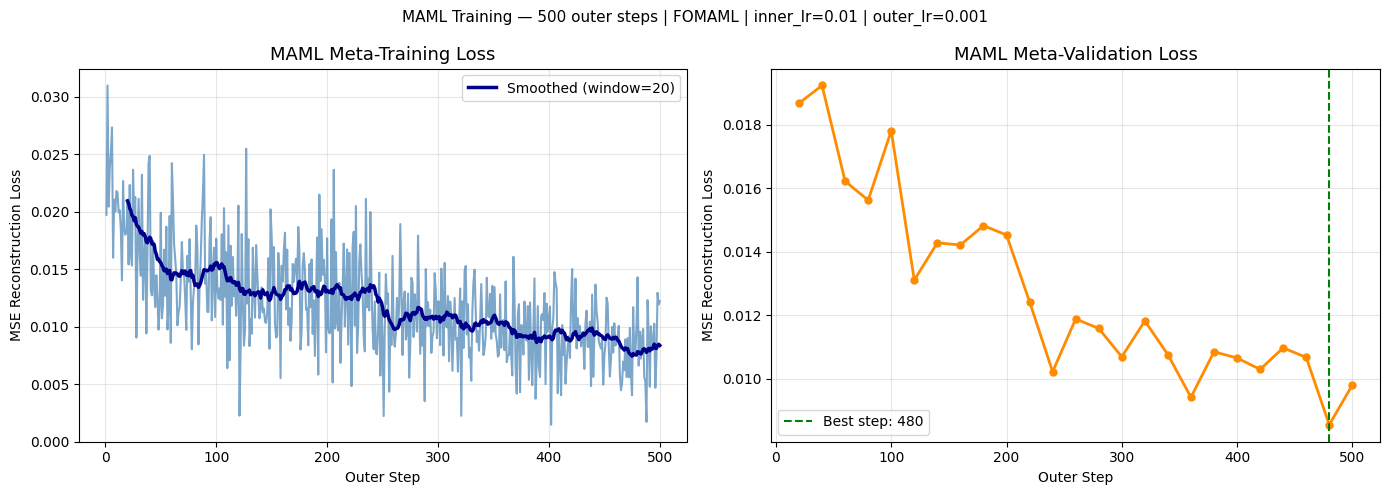

✅ Training curves saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Training loss
axes[0].plot(range(1, len(train_losses)+1), train_losses,
             color='steelblue', linewidth=1.5, alpha=0.7)

# Smoothed line — easier to see the trend
window    = min(20, len(train_losses)//4)
smoothed  = np.convolve(train_losses,
                        np.ones(window)/window, mode='valid')
axes[0].plot(range(window, len(train_losses)+1), smoothed,
             color='darkblue', linewidth=2.5,
             label=f'Smoothed (window={window})')
axes[0].set_title("MAML Meta-Training Loss", fontsize=13)
axes[0].set_xlabel("Outer Step")
axes[0].set_ylabel("MSE Reconstruction Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Validation loss
if val_losses:
    axes[1].plot(val_steps, val_losses,
                 color='darkorange', linewidth=2,
                 marker='o', markersize=5)
    axes[1].axvline(x=best_step, color='green',
                    linestyle='--', linewidth=1.5,
                    label=f'Best step: {best_step}')
    axes[1].set_title("MAML Meta-Validation Loss", fontsize=13)
    axes[1].set_xlabel("Outer Step")
    axes[1].set_ylabel("MSE Reconstruction Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle(f"MAML Training — {N_OUTER_STEPS} outer steps | "
             f"FOMAML | inner_lr={INNER_LR} | "
             f"outer_lr={OUTER_LR}", fontsize=11)
plt.tight_layout()
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/maml_training_curves.png", dpi=150)
plt.show()
print("✅ Training curves saved")

# Cell 8 — Load Best Model and Quick Sanity Check

In [12]:
# Load the best saved model
checkpoint = torch.load("models/checkpoints/maml_best.pt",
                        map_location=DEVICE)

maml.load_state_dict(checkpoint['maml_state_dict'])
print(f"Best model loaded")
print(f"  Saved at step    : {checkpoint['step']}")
print(f"  Validation loss  : {checkpoint['val_loss']:.6f}")
print(f"  Hyperparameters  : {checkpoint['hyperparameters']}")

# Quick check — does adapted model separate normal vs anomaly?
print(f"\nQuick sanity check on one META-TEST channel...")
print(f"(Meta-test channels never seen during training)")

test_ch = task_splits['meta_test'][0]
print(f"Channel : {test_ch}")

# Get normal windows for adaptation (support set)
normal_wins  = channel_data[test_ch]['normal_windows']
anomaly_wins = channel_data[test_ch]['anomaly_windows']

support = torch.tensor(
    normal_wins[:SUPPORT_SIZE], dtype=torch.float32)
normal_query = torch.tensor(
    normal_wins[SUPPORT_SIZE:SUPPORT_SIZE+30], dtype=torch.float32)
anomaly_query = torch.tensor(
    anomaly_wins[:30], dtype=torch.float32)

# Adapt to this new channel
learner = maml.clone()
for step in range(INNER_STEPS):
    recon = learner(support)
    loss  = criterion(recon, support)
    learner.adapt(loss)

# Check reconstruction errors after adaptation
learner.eval()
with torch.no_grad():
    normal_scores  = learner.reconstruction_error(normal_query)
    anomaly_scores = learner.reconstruction_error(anomaly_query)

n_mean = normal_scores.mean().item()
a_mean = anomaly_scores.mean().item()
ratio  = a_mean / n_mean if n_mean > 0 else 0

print(f"\nAfter MAML adaptation on {SUPPORT_SIZE} normal windows:")
print(f"  Normal  reconstruction error : {n_mean:.5f}")
print(f"  Anomaly reconstruction error : {a_mean:.5f}")
print(f"  Separation ratio             : {ratio:.2f}x")

if ratio > 1.5:
    print(f"\n✅ Strong separation — MAML training successful")
elif ratio > 1.2:
    print(f"\n✅ Good separation — more training steps will improve")
elif ratio > 1.0:
    print(f"\n⚠️ Weak separation — try 500+ steps or move to Colab")
else:
    print(f"\n⚠️ No separation yet — need more training steps")
    print(f"   Move to Colab and run 3000 steps for full training")

Best model loaded
  Saved at step    : 480
  Validation loss  : 0.008547
  Hyperparameters  : {'inner_lr': 0.01, 'outer_lr': 0.001, 'inner_steps': 5, 'tasks_per_batch': 4, 'support_size': 20, 'query_size': 20, 'first_order': True}

Quick sanity check on one META-TEST channel...
(Meta-test channels never seen during training)
Channel : E-3

After MAML adaptation on 20 normal windows:
  Normal  reconstruction error : 0.01383
  Anomaly reconstruction error : 0.00882
  Separation ratio             : 0.64x

⚠️ No separation yet — need more training steps
   Move to Colab and run 3000 steps for full training


# Step 1 — Check All Nine Meta-Test Channels

In [13]:
print("Checking separation ratio across ALL meta-test channels")
print("=" * 55)

test_results = {}

for test_ch in meta_test_25:
    try:
        normal_wins  = channel_data[test_ch]['normal_windows']
        anomaly_wins = channel_data[test_ch]['anomaly_windows']

        # Need enough windows
        if len(normal_wins) < SUPPORT_SIZE + 10:
            print(f"  {test_ch}: skipped — insufficient normal windows")
            continue
        if len(anomaly_wins) < 5:
            print(f"  {test_ch}: skipped — insufficient anomaly windows")
            continue

        # Support set — normal windows for adaptation
        support = torch.tensor(
            normal_wins[:SUPPORT_SIZE], dtype=torch.float32)

        # Query sets
        normal_query  = torch.tensor(
            normal_wins[SUPPORT_SIZE:SUPPORT_SIZE+20],
            dtype=torch.float32)
        anomaly_query = torch.tensor(
            anomaly_wins[:20], dtype=torch.float32)

        # Adapt to this channel
        learner = maml.clone()
        for _ in range(INNER_STEPS):
            recon = learner(support)
            loss  = criterion(recon, support)
            learner.adapt(loss)

        # Measure separation
        learner.eval()
        with torch.no_grad():
            n_scores = learner.reconstruction_error(normal_query)
            a_scores = learner.reconstruction_error(anomaly_query)

        n_mean = n_scores.mean().item()
        a_mean = a_scores.mean().item()
        ratio  = a_mean / n_mean if n_mean > 0 else 0

        test_results[test_ch] = {
            'normal_mean'  : round(n_mean, 5),
            'anomaly_mean' : round(a_mean, 5),
            'ratio'        : round(ratio, 3)
        }

        direction = "✅" if ratio > 1.0 else "❌"
        print(f"  {test_ch:6s} | Normal: {n_mean:.5f} | "
              f"Anomaly: {a_mean:.5f} | "
              f"Ratio: {ratio:.2f}x {direction}")

    except Exception as e:
        print(f"  {test_ch}: error — {e}")

# Summary
ratios = [v['ratio'] for v in test_results.values()]
positive = sum(1 for r in ratios if r > 1.0)
#print(f"\nSummary after 100 training steps:")
print(f"Summary after {N_OUTER_STEPS} training steps:")
print(f"  Channels tested           : {len(test_results)}")
print(f"  Positive separation (>1x) : {positive}/{len(test_results)}")
print(f"  Average ratio             : {np.mean(ratios):.3f}x")
print(f"  Best ratio                : {max(ratios):.3f}x")
print(f"  Worst ratio               : {min(ratios):.3f}x")

Checking separation ratio across ALL meta-test channels
  E-3    | Normal: 0.01250 | Anomaly: 0.00837 | Ratio: 0.67x ❌
  D-7    | Normal: 0.01622 | Anomaly: 0.02576 | Ratio: 1.59x ✅
  E-6    | Normal: 0.01417 | Anomaly: 0.01902 | Ratio: 1.34x ✅
  D-12: skipped — insufficient normal windows
  D-6    | Normal: 0.01359 | Anomaly: 0.01943 | Ratio: 1.43x ✅
  T-2    | Normal: 0.01523 | Anomaly: 0.00227 | Ratio: 0.15x ❌
  A-6    | Normal: 0.00853 | Anomaly: 0.00358 | Ratio: 0.42x ❌
  D-3    | Normal: 0.01033 | Anomaly: 0.00872 | Ratio: 0.84x ❌
  P-4    | Normal: 0.01682 | Anomaly: 0.00204 | Ratio: 0.12x ❌
Summary after 500 training steps:
  Channels tested           : 8
  Positive separation (>1x) : 3/8
  Average ratio             : 0.820x
  Best ratio                : 1.588x
  Worst ratio               : 0.121x


# Cell 9 — Save Training Summary

In [14]:
import json

training_summary = {
    'n_outer_steps'   : N_OUTER_STEPS,
    'inner_lr'        : INNER_LR,
    'outer_lr'        : OUTER_LR,
    'inner_steps'     : INNER_STEPS,
    'tasks_per_batch' : TASKS_PER_BATCH,
    'support_size'    : SUPPORT_SIZE,
    'query_size'      : QUERY_SIZE,
    'first_order'     : True,
    'best_step'       : best_step,
    'best_val_loss'   : best_val,
    'final_train_loss': train_losses[-1],
    'training_time_s' : round(total_time, 1),
    'meta_test_channel_checked' : test_ch,
    'separation_ratio_quick_check' : round(ratio, 3),
}

with open("results/training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

print("=" * 55)
print("NOTEBOOK 4 COMPLETE")
print("=" * 55)
print()
print("What was done:")
print(f"  ✅ MAML wrapped around LSTM-AE")
print(f"  ✅ {N_OUTER_STEPS} outer steps completed")
print(f"  ✅ Best model saved at step {best_step}")
print(f"  ✅ Training and validation curves plotted")
print(f"  ✅ Quick sanity check on held-out test channel")
print()
print("Saved files:")
print("  models/checkpoints/maml_best.pt")
print("  results/figures/maml_training_curves.png")
print("  results/training_summary.json")
print()
if ratio > 1.5:
    print("Next: Notebook 5 — Full Evaluation")
else:
    print("Recommended: Run on Colab with 3000 steps")
    print("Then: Notebook 5 — Full Evaluation")

NOTEBOOK 4 COMPLETE

What was done:
  ✅ MAML wrapped around LSTM-AE
  ✅ 500 outer steps completed
  ✅ Best model saved at step 480
  ✅ Training and validation curves plotted
  ✅ Quick sanity check on held-out test channel

Saved files:
  models/checkpoints/maml_best.pt
  results/figures/maml_training_curves.png
  results/training_summary.json

Recommended: Run on Colab with 3000 steps
Then: Notebook 5 — Full Evaluation


In [15]:
m, _, _ = load_lstm(PATH_30000)
print(sum(p.numel() for p in m.parameters()))

NameError: name 'load_lstm' is not defined